In [ ]:
#AI use: Used Chat GPT to help generate code.

In [ ]:
#Imports and Device Set up

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import norse
from norse.torch import LIFCell

import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Norse:", norse.__version__)
print("HIP:", torch.version.hip)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.9.1+rocm7.2.1
Norse: 1.1.1.dev34+ge4a273b05
HIP: 7.2.53211-158bd99533
Device: cuda
GPU: AMD Radeon RX 9070 XT


In [ ]:
#Loading the MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Training samples: 60000
Testing samples: 10000


In [ ]:
#Makeing the Dataloader (Aside at the moment Im keeping the batch size some while I mess around with the paramaters.

In [7]:
batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True
)

num_workers=0

In [ ]:
#Makeing sure that looks right by plotting the MNIST image

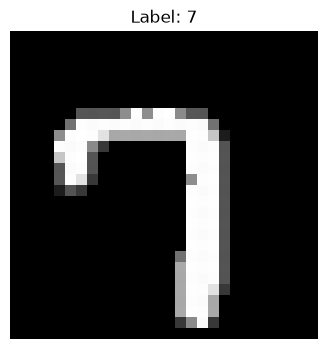

Image shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])


In [8]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(4, 4))
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)

In [ ]:
#Now we gotta make the image into spikes

In [ ]:
#Here is a good visual that Chat gave me to help me understand how it was working
#pixel intensity → neuron
#bright pixel → • • • • • •
#gray pixel   → •   •     •
#dark pixel   →       •
#black pixel  → 

In [10]:
num_steps = 25

def poisson_encode(images, num_steps):
    """
    Convert MNIST images into Poisson spike trains.

    images:
        [batch, 1, 28, 28]

    returns:
        [time, batch, 784]
    """
    images = images.to(device)

    images = images.view(images.size(0), -1)

    # Repeat the image for every timestep
    rates = images.unsqueeze(0).repeat(num_steps, 1, 1)

    # Bernoulli sampling gives spikes
    spikes = torch.rand_like(rates) < rates

    return spikes.float()

In [ ]:
#Quick lil test to make sure that paisoon function is working

In [11]:
spikes = poisson_encode(images[:4], num_steps)

print("Spike tensor:", spikes.shape)
print("Spike values:", spikes.unique())

Spike tensor: torch.Size([25, 4, 784])
Spike values: tensor([0., 1.], device='cuda:0')


In [ ]:
#Lets see dem spikes (aside this visual is a bit stange to me. I went on kinda of a wild goose chase trying to understand why it looks like this. This might be wrong.
# In some ways it makes sense because the image is just black and white pixels so the white pixels have a 100% chance of firing, so once we get around the 200 input neurons start firing at each time step cause they are white.
# Below all this Ill have a different encode that makes it so a white pixel only has a 30% chance to fire in hopes of getting a better visual.)

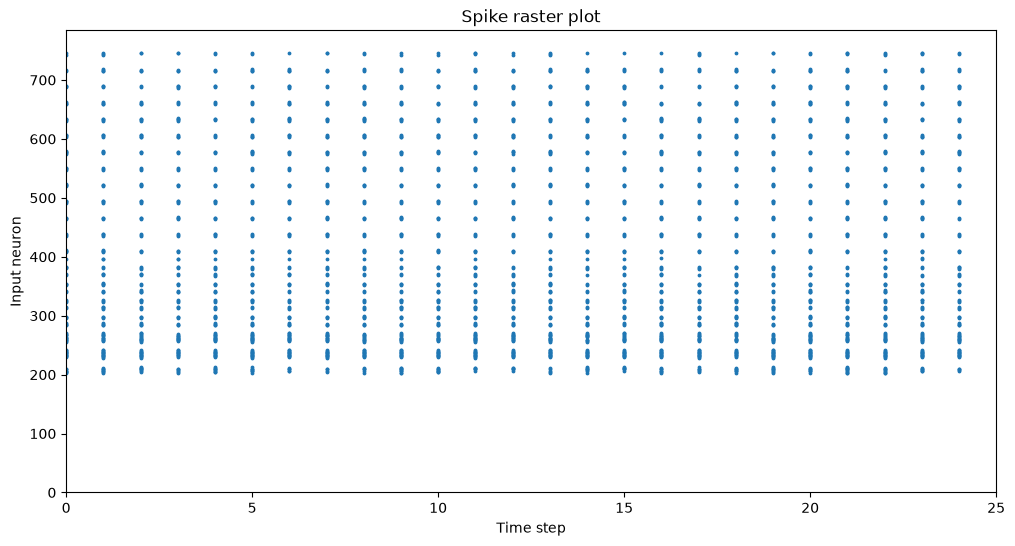

In [23]:
# Take the first image
spike_train = spikes[:, 0].detach().cpu()

# Find where spikes occurred
time_indices, neuron_indices = torch.where(spike_train > 0)

plt.figure(figsize=(12, 6))

plt.scatter(
    time_indices,
    neuron_indices,
    s=3
)

plt.xlabel("Time step")
plt.ylabel("Input neuron")
plt.title("Spike raster plot")

plt.xlim(0, num_steps)
plt.ylim(0, 784)

plt.show()

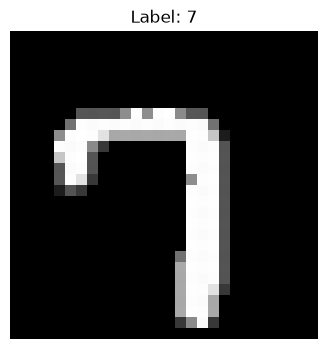

In [15]:
plt.figure(figsize=(4, 4))
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [16]:
print("Image min:", images[0].min().item())
print("Image max:", images[0].max().item())
print("Image mean:", images[0].mean().item())

Image min: 0.0
Image max: 1.0
Image mean: 0.12815627455711365


In [17]:
spike_rates = spikes[:, 0].mean(dim=0)

print("Number of neurons:", spike_rates.numel())
print("Minimum firing rate:", spike_rates.min().item())
print("Maximum firing rate:", spike_rates.max().item())
print("Average firing rate:", spike_rates.mean().item())

Number of neurons: 784
Minimum firing rate: 0.0
Maximum firing rate: 1.0
Average firing rate: 0.12943877279758453


In [ ]:
#Just showing where the whit pixels are.

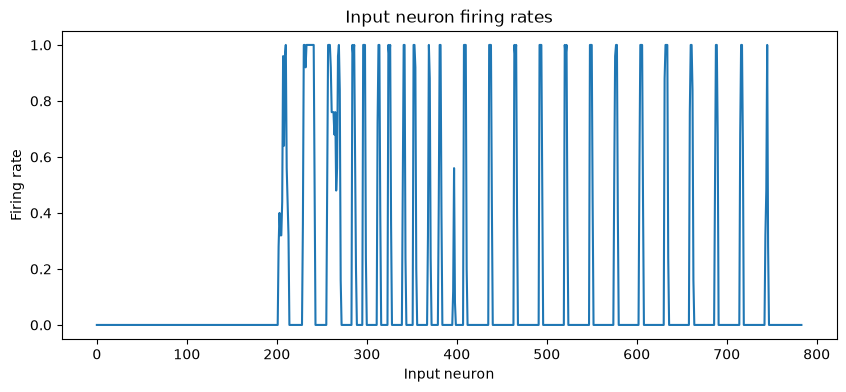

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    spike_rates.detach().cpu()
)

plt.xlabel("Input neuron")
plt.ylabel("Firing rate")
plt.title("Input neuron firing rates")

plt.show()

In [ ]:
#Wanted to check to make sure that the intensity vs spike rate was correct.
# It is as you can see becasue black pixel never fir, while white ones always fire

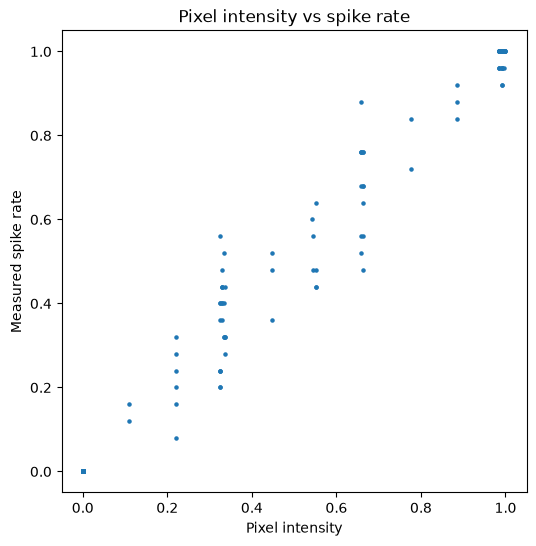

In [19]:
pixel_values = images[0].view(-1).cpu()
measured_rates = spikes[:, 0].mean(dim=0).detach().cpu()

plt.figure(figsize=(6, 6))

plt.scatter(
    pixel_values,
    measured_rates,
    s=5
)

plt.xlabel("Pixel intensity")
plt.ylabel("Measured spike rate")
plt.title("Pixel intensity vs spike rate")

plt.show()

In [20]:
print("Image min:", images[0].min().item())
print("Image max:", images[0].max().item())
print("Image mean:", images[0].mean().item())

print("Minimum firing rate:", spike_rates.min().item())
print("Maximum firing rate:", spike_rates.max().item())
print("Average firing rate:", spike_rates.mean().item())

Image min: 0.0
Image max: 1.0
Image mean: 0.12815627455711365
Minimum firing rate: 0.0
Maximum firing rate: 1.0
Average firing rate: 0.12943877279758453


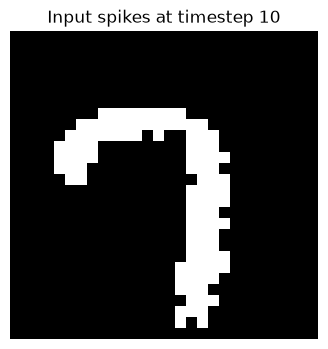

In [21]:
# Show the spike pattern at one timestep
t = 10

plt.figure(figsize=(4, 4))

plt.imshow(
    spikes[t, 0].view(28, 28).detach().cpu(),
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(f"Input spikes at timestep {t}")
plt.axis("off")
plt.show()

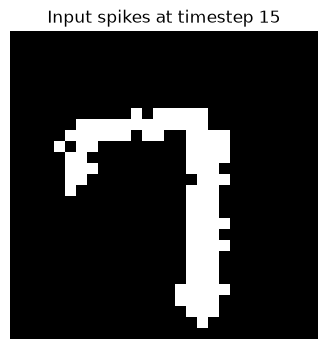

In [22]:
# Show the spike pattern at one timestep
t = 15

plt.figure(figsize=(4, 4))

plt.imshow(
    spikes[t, 0].view(28, 28).detach().cpu(),
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(f"Input spikes at timestep {t}")
plt.axis("off")
plt.show()

In [ ]:
#Here is the new encoder with the max prob that a neuron has of firing is 30%

In [24]:
def poisson_encode_Max30(images, num_steps, max_rate=0.3):
    """
    Convert MNIST images into Poisson/Bernoulli spike trains.

    images:
        [batch, 1, 28, 28]

    returns:
        [time, batch, 784]
    """

    images = images.to(device)

    # Flatten 28x28 image into 784 input neurons
    images = images.view(images.size(0), -1)

    # Convert pixel intensity into firing probability
    rates = images * max_rate

    # Repeat rates across time
    rates = rates.unsqueeze(0).expand(
        num_steps,
        -1,
        -1
    )

    # Generate spikes
    spikes = torch.rand_like(rates) < rates

    return spikes.float()

In [25]:
spikes_Max30 = poisson_encode_Max30(images, num_steps)

In [27]:
spike_rates_Max30 = spikes_Max30[:, 0].mean(dim=0)

print("Minimum firing rate:", spike_rates_Max30.min().item())
print("Maximum firing rate:", spike_rates_Max30.max().item())
print("Average firing rate:", spike_rates_Max30.mean().item())

Minimum firing rate: 0.0
Maximum firing rate: 0.47999998927116394
Average firing rate: 0.037551019340753555


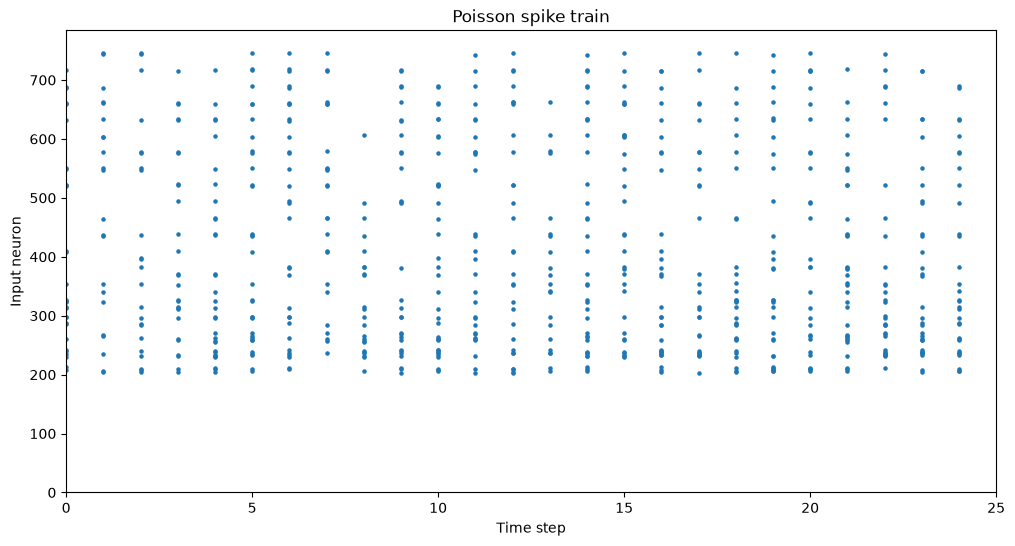

In [28]:
spike_train_Max30 = spikes_Max30[:, 0].detach().cpu()

time_indices, neuron_indices = torch.where(spike_train_Max30 > 0)

plt.figure(figsize=(12, 6))

plt.scatter(
    time_indices,
    neuron_indices,
    s=5
)

plt.xlabel("Time step")
plt.ylabel("Input neuron")
plt.title("Poisson spike train")

plt.xlim(0, num_steps)
plt.ylim(0, 784)

plt.show()

In [ ]:
#Ok now that Im done with that crazy goose chase Im ready to work on the SNN

In [29]:
class MNISTSNN(nn.Module):

    def __init__(self, input_size=784, hidden_size=256, output_size=10):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)

        self.lif = LIFCell()

        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # x shape:
        # [time, batch, 784]

        time_steps = x.shape[0]

        state = None

        outputs = []

        for t in range(time_steps):

            # Input → hidden weights
            hidden = self.fc1(x[t])

            # Hidden LIF neurons
            spikes, state = self.lif(hidden, state)

            # Hidden → output
            output = self.fc2(spikes)

            outputs.append(output)

        # [time, batch, 10]
        return torch.stack(outputs)

In [30]:
model = MNISTSNN().to(device)

print(model)

MNISTSNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (lif): LIFCell(p=LIFParameters(tau_syn_inv=tensor(200.), tau_mem_inv=tensor(100.), v_leak=tensor(0.), v_th=tensor(1.), v_reset=tensor(0.), method='super', alpha=tensor(100.)), dt=0.001)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
#Making the Optimizer (Starting with Adam, but can always use a different one

In [31]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

In [ ]:
#OK now for the training function 

In [32]:
def train_one_epoch(model, loader, optimizer, criterion, num_steps):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Convert images → spike trains
        spikes = poisson_encode(images, num_steps)

        optimizer.zero_grad()

        # Run the SNN
        outputs = model(spikes)

        # outputs:
        # [time, batch, 10]

        # Average output activity over time
        logits = outputs.mean(dim=0)

        loss = criterion(logits, labels)

        # BPTT
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

In [ ]:
#OK now for the testing function

In [33]:
@torch.no_grad()
def evaluate(model, loader, num_steps):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        spikes = poisson_encode(images, num_steps)

        outputs = model(spikes)

        logits = outputs.mean(dim=0)

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [ ]:
#K lets run this sucker

In [35]:
num_epochs = 20

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):

    loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        num_steps
    )

    test_acc = evaluate(
        model,
        test_loader,
        num_steps
    )

    train_losses.append(loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {loss:.4f} | "
        f"Train Acc: {train_acc * 100:.2f}% | "
        f"Test Acc: {test_acc * 100:.2f}%"
    )

Epoch 1/20 | Loss: 0.0962 | Train Acc: 97.33% | Test Acc: 96.87%
Epoch 2/20 | Loss: 0.0826 | Train Acc: 97.68% | Test Acc: 96.91%
Epoch 3/20 | Loss: 0.0716 | Train Acc: 97.97% | Test Acc: 97.40%
Epoch 4/20 | Loss: 0.0622 | Train Acc: 98.25% | Test Acc: 97.31%
Epoch 5/20 | Loss: 0.0551 | Train Acc: 98.48% | Test Acc: 97.58%
Epoch 6/20 | Loss: 0.0487 | Train Acc: 98.70% | Test Acc: 97.48%
Epoch 7/20 | Loss: 0.0425 | Train Acc: 98.84% | Test Acc: 97.66%
Epoch 8/20 | Loss: 0.0377 | Train Acc: 99.04% | Test Acc: 97.80%
Epoch 9/20 | Loss: 0.0346 | Train Acc: 99.12% | Test Acc: 97.79%
Epoch 10/20 | Loss: 0.0305 | Train Acc: 99.23% | Test Acc: 97.75%
Epoch 11/20 | Loss: 0.0273 | Train Acc: 99.34% | Test Acc: 97.93%
Epoch 12/20 | Loss: 0.0241 | Train Acc: 99.47% | Test Acc: 97.76%
Epoch 13/20 | Loss: 0.0213 | Train Acc: 99.52% | Test Acc: 97.94%
Epoch 14/20 | Loss: 0.0192 | Train Acc: 99.62% | Test Acc: 98.10%
Epoch 15/20 | Loss: 0.0177 | Train Acc: 99.65% | Test Acc: 97.97%
Epoch 16/20 | Loss:

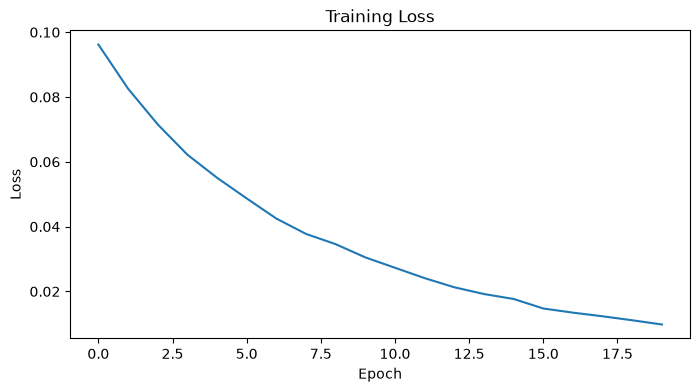

In [36]:
plt.figure(figsize=(8, 4))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

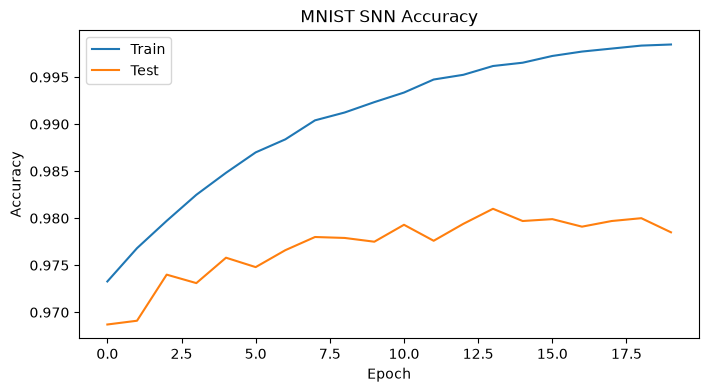

In [37]:
plt.figure(figsize=(8, 4))

plt.plot(train_accuracies, label="Train")
plt.plot(test_accuracies, label="Test")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MNIST SNN Accuracy")

plt.legend()
plt.show()